In [2]:
from math import pi

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter

import numpy as np
import scipy
import tqdm
import xarray as xr

from fluxoniumcr import DATA_DIR
from fluxoniumcr.plotting.cookbook import colorline, plot_triangle
from fluxoniumcr.qubits.fluxonium import Fluxonium

plt.style.use("fluxoniumcr.plotting.paper")

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [8]:
EJc = 5.60
ECc = 1.87
ELc = 0.56

EJt = 3.52
ECt = 1.18
ELt = 0.88

JC = 97e-3

parent_path = DATA_DIR/"time_domain"/f"{EJc=:.2f},{ECc=:.2f},{ELc=:.2f},{EJt=:.2f},{ECt=:.2f},{ELt=:.2f},{JC=:.3f}"
dataset_ramp_sweep = xr.load_dataset(parent_path/"planck_taper_ramp_duration_sweep.hdf5")
dataset_amplitude_sweep = xr.load_dataset(parent_path/"planck_taper_amplitude_sweep.hdf5")

In [9]:
from matplotlib.colors import LinearSegmentedColormap

myblues = LinearSegmentedColormap.from_list(
    "myblues",
    [
        "#f7fbff",
        "#deebf7",
        "#c6dbef",
        "#9ecae1",
        "#6baed6",
        "#4292c6",
        "#2171b5",
        "#08519c",
        "#08306b",
    ]
)

In [10]:
def add_subfig_label(ax, subfig_label):
    annotation = ax.annotate(
        subfig_label,
        (0.00, 1.00),
        (-36, 0),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="right",
        va="top",
        zorder=1,
    )
    
    return annotation

# Forgive me but I'm about to calculate in the plotting notebook...

In [11]:
sigmax = np.array([
    [0, 1],
    [1, 0],
])
sigmay = np.array([
    [0, -1j],
    [1j, 0],
])
sigmaz = np.array([
    [1, 0],
    [0, -1],
])
sigma0 = np.array([
    [1, 0],
    [0, 1],
])
phase_error_data = []
for amp in dataset_amplitude_sweep.amplitude.data:
    ds = dataset_amplitude_sweep.sel(amplitude=amp)
    if np.isnan(ds.fidelity):
        phase_error_data.append(np.nan)
        continue
    M = ds.matrix.squeeze().data.reshape(4, 4)
    U, S, Vdg = np.linalg.svd(M)
    M_unit = U@Vdg

    err = sum(
        4/5 * abs((M_unit * 0.25*np.kron(A, B)).sum())**2
        for A, B in [
            [sigmaz, sigmaz],
            [sigma0, sigmaz],
        ]
    )
    phase_error_data.append(err)
phase_error_data = np.array(phase_error_data)

In [12]:
from fluxoniumcr.dressed_control_fluxonium import (
    create_driven_fluxonium,
    calculate_polarization_and_error,
)
from fluxoniumcr.simulation.signals import planck_taper_signal


fx1 = Fluxonium(
    EJ=EJ1 * 2*pi,
    EC=EC1 * 2*pi,
    EL=EL1 * 2*pi,
    flux=0.5,
    dim=16,
    cutoff=128,
)
fx2 = Fluxonium(
    EJ=EJ2 * 2*pi,
    EC=EC2 * 2*pi,
    EL=EL2 * 2*pi,
    flux=0.5,
    dim=16,
    cutoff=128,
)
n1_op = fx1.get_operator('charge')
n2_op = fx2.get_operator('charge')

qubit_frequency = fx1.eigenvalues[1] - fx1.eigenvalues[0]
Ω0 = qubit_frequency/abs(n1_op[0, 1])

drive_freq = dataset_amplitude_sweep.frequency.mean().item()

floquet_basis = create_driven_fluxonium(
    fx1,
    drive_freq,
    deg_tol=1e-3 * 2*pi,
    phase_gauge=True,
)
lookup_deg_tol = 10e-3 * 2*pi
lookup_amps = Ω0 * np.linspace(0, 1.3, 131)
floquet_basis.generate_lookup(
    lookup_amps,
    deg_tol=lookup_deg_tol,
)

In [18]:
def calculate_cnot_rate(amplitude, ramp_duration):
    drive_signal = planck_taper_signal(
        amplitude,
        2*ramp_duration,
        ramp_duration,
    )
    ramp_fraction, integral_err = scipy.integrate.quad(
        lambda t: np.interp(drive_signal(t), lookup_amps, cnot_rate_data),
        0,
        2*ramp_duration,
    )
    plateau_rate = np.interp(amplitude, lookup_amps, cnot_rate_data)
    plateau_duration = (1 - ramp_fraction)/plateau_rate
    return 1/(plateau_duration + 2*ramp_duration)

In [19]:
cnot_rate_semi_analytic_data = []
for amp in tqdm.tqdm(dataset_amplitude_sweep.amplitude.data):
    ds = dataset_amplitude_sweep.sel(amplitude=amp)
    cnot_rate_semi_analytic_data.append(
        calculate_cnot_rate(amp, ds.ramp_duration.item())
    )
cnot_rate_semi_analytic_data = np.array(cnot_rate_semi_analytic_data)

  4%|█▊                                               | 45/1191 [00:00<00:29, 39.44it/s]/tmp/ipykernel_757821/3735694.py:7: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  ramp_fraction, integral_err = scipy.integrate.quad(
  8%|███▊                                             | 92/1191 [00:03<01:21, 13.54it/s]/tmp/ipykernel_757821/3735694.py:7: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  ramp_fraction, integral_err = scipy.integrate.quad(
100%|████████████████

# Plotting

In [20]:
def plot_error_vs_ramp_duration(ax, dataset):
    legend_elements = []
    for amp, ds in dataset.groupby('amplitude'):
        color = myblues(0.2 + 0.8*amp/dataset.amplitude.max())
        ax.plot(
            ds.ramp_duration.squeeze(),
            1 - ds.fidelity.squeeze(),
            c=color,
            markersize=2,
            marker='',
            linestyle='-',
            markeredgewidth=0,
            markeredgecolor='none',
        )
        legend_elm = Line2D(
            [0], [0],
            marker='',
            linestyle='-',
            markerfacecolor=color,
            color=color,
            markersize=3,
            markeredgecolor='none',
            markeredgewidth=0,
            label=f"${amp/dataset.amplitude.plot_unit:.1f}$",
        )
        legend_elements.append(legend_elm)
    
    legend = ax.legend(
        handles=legend_elements[::-1],
        handlelength=0.5,
        handletextpad=0.6,
        labelspacing=0.3,
        reverse=True,
        loc='upper right',
        bbox_to_anchor=(1, 1),
        borderpad=0,
    )
    offset_from = mpl.text.OffsetFrom(legend, (0.0, 1.0))
    ax.annotate(
        r"$\Omega_\mathrm{m} |n^{01}_\mathrm{c}|/\omega^{10}_\mathrm{c}=$",
        (0, 0),
        xytext=(2 - legend.handletextpad * 9, -6.25),
        xycoords=offset_from,
        textcoords='offset points',
        va='baseline',
        ha='right',
    )
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(2, 100)
    ax.set_ylim(1e-6, 1.5e-1)
    ax.set_xlabel("Ramp duration $t_\mathrm{r}$ [ns]")
    ax.set_ylabel("Avg. infidelity")
    ax.xaxis.set_major_formatter(lambda x, _: "{:.0f}".format(x))
    ax.xaxis.set_minor_formatter(lambda x, _: "{:.0f}".format(x) if x in (2, 5, 20, 50) else '')


In [21]:
def plot_error_vs_amplitude(ax, dataset, phase_error_data):
    ax.plot(
        dataset.amplitude.squeeze()/dataset.amplitude.plot_unit,
        1 - dataset.fidelity.squeeze(),
        c='C3',
        label="Coherent"
    )
    
    # 1ms T1 limit
    ax.plot(
        dataset.amplitude/dataset.amplitude.plot_unit,
        1 - dataset.fidelity.squeeze() + (4/5 * dataset.total_duration.squeeze().data * 1/1e6),
        c='lightgray',
        zorder=-10,
        label="$T_1=1\,\mathrm{ms}$"
    )
    
    ax.plot(
        dataset.amplitude/dataset.amplitude.plot_unit,
        phase_error_data,
        c='C4',
        ls='-.',
        zorder=2,
#         lw=0.9*plt.rcParams['lines.linewidth'],
        label=r"Phase $IZ$, $ZZ$"
    )
    
    i10 = dataset.state[
        (dataset.state_label.sel(subsystem='control') == 1)
        & (dataset.state_label.sel(subsystem='target') == 0)
    ].item()
    i11 = dataset.state[
        (dataset.state_label.sel(subsystem='control') == 1)
        & (dataset.state_label.sel(subsystem='target') == 1)
    ].item()
    i02 = dataset.state[
        (dataset.state_label.sel(subsystem='control') == 0)
        & (dataset.state_label.sel(subsystem='target') == 2)
    ].item()
    
    leakage = 0.25 * (
        abs(dataset.unitary.sel(final_state=i02, initial_state=i10))**2
        + abs(dataset.unitary.sel(final_state=i02, initial_state=i11))**2
    )
    ax.plot(
        dataset.amplitude/dataset.amplitude.plot_unit,
        leakage,
        c='C5',
        ls='--',
        zorder=2,
#         lw=0.9*plt.rcParams['lines.linewidth'],
        label=r"Leakage $1\pm \to 02$"
    )
    
    ax.set_yscale('log')
    ax.set_ylim(1e-6, 1e-2)#(1 - dataset.fidelity).max())
    ax.set_ylabel("Avg. infidelity")
    
    ticklocs = ax.yaxis.get_majorticklocs()
    ax.set_yticks(ticklocs[(ticklocs > ax2.get_ylim()[0]) & (ticklocs <= ax2.get_ylim()[1])])
    
    ax.annotate(
        "$t_r=" + f"{dataset.ramp_duration.item():.0f}" + "\,\mathrm{ns}$",
        (0, 0),
        xytext=(+4, +4),
        xycoords='axes fraction',
        textcoords='offset points',
        ha='left',
        va='bottom',
    )
    ax.legend(
        handlelength=1.,
        handletextpad=0.6,
        labelspacing=0.4,
        loc='upper right',
        bbox_to_anchor=(1.02, 1),
        borderpad=0,
        ncols=2,
        columnspacing=0.6,
    )

def plot_total_duration_vs_amplitude(ax, dataset, cnot_rate_semi_analytic_data, subfig_label=''):
    numerical_color = 'C0'
    semianalytic_color = 'C1'
    
    ax.plot(
        [0, *(dataset.amplitude.squeeze()/dataset.amplitude.plot_unit)],
        [0, *(1/dataset.total_duration.squeeze() * 1e3)],
        c=numerical_color,
    )
    
    ax.plot(
        [0, *(dataset.amplitude.squeeze()/dataset.amplitude.plot_unit)],
        [0, *(cnot_rate_semi_analytic_data * 1e3)],
        c=semianalytic_color,
        ls='--',
        dashes=(3, 3),
    )
    
#     ax.set_yscale('log')
#     ax.set_ylim(100, dataset.total_duration.max())
    ax.set_xlabel(r"Midpoint amplitude $\Omega_\mathrm{m} |n^{10}_\mathrm{c}|/\omega^{10}_\mathrm{c}$")
    ax.set_ylabel("Gate rate $1/t_\mathrm{p}$ [MHz]", labelpad=-6)
#     amp_opt = dataset.amplitude[dataset.infidelity.argmin()].item()
#     ax.axvline(amp_opt/Ω0, c='lightgray', zorder=0)
    
#     ax.yaxis.set_major_formatter(lambda x, _: "{:.0f}".format(x))
#     ax.yaxis.set_minor_formatter(lambda x, _: "{:.0f}".format(x) if x in (200, 500, 2000) else '')
    
#     delta_polarization_data = dataset_floquet.polarizations.diff('qubit_label').data.ravel()
#     ax.plot(
#         dataset_floquet.amplitude.squeeze()/(2*pi)/dataset.amplitude.plot_unit,
#         0.25/(J12*nc01*nt01 * abs(delta_polarization_data)),
#         c=semianalytic_color,
#         ls='--',
#         zorder=0,
#     )
    
    legend_elements = [
        Line2D(
            [0], [0],
            marker='',
            linestyle='-',
            color=numerical_color,
            label=f"Numerical",
        ),
        Line2D(
            [0], [0],
            marker='',
            linestyle='--',
            dashes=(3, 3),
            color=semianalytic_color,
            label=f"Semi-analytical",
        ),
    ]
    ax.legend(
        handles=legend_elements,
        handlelength=1.,
        handletextpad=0.6,
        labelspacing=0.4,
        loc='lower right',
        bbox_to_anchor=(1, 0),
        borderpad=0,
    )

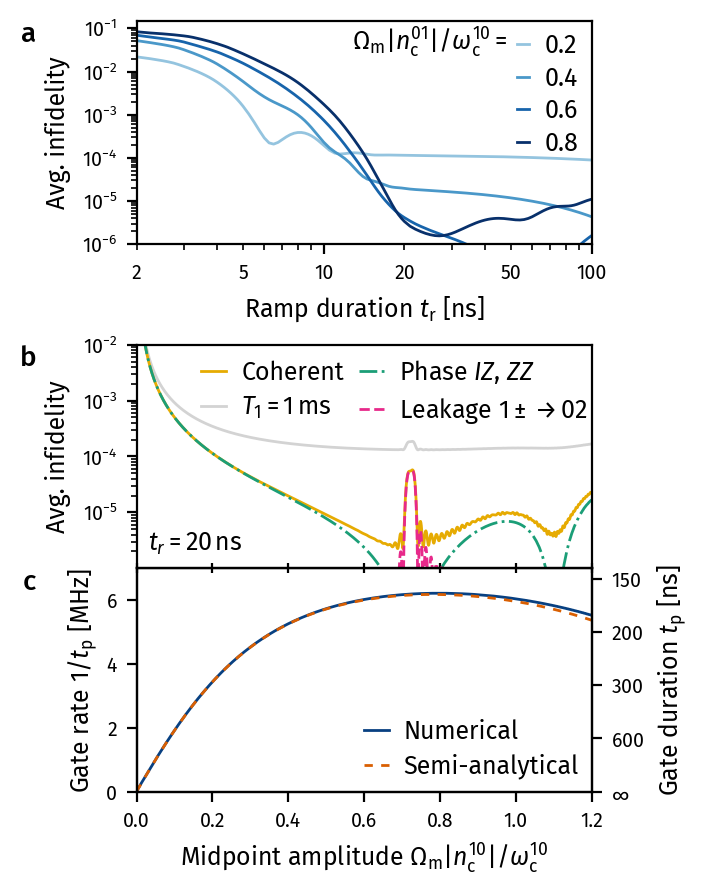

In [22]:
fig = plt.figure(
    figsize=(85/25.4, 110/25.4),
)

outer = mpl.gridspec.GridSpec(2, 1, height_ratios=[1, 2]) 
gs1 = mpl.gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=outer[0])
gs2 = mpl.gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[1], hspace=0, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs1[0])
ax3 = fig.add_subplot(gs2[1])
ax2 = fig.add_subplot(gs2[0], sharex=ax3)
ax2.tick_params(axis='x', which='both', labelbottom=False, direction='inout')

plot_error_vs_ramp_duration(ax1, dataset_ramp_sweep)
plot_error_vs_amplitude(ax2, dataset_amplitude_sweep, phase_error_data)
plot_total_duration_vs_amplitude(ax3, dataset_amplitude_sweep, cnot_rate_semi_analytic_data)

ax3.set_xlim(0, 1.2)
ax3.set_ylim(0, 7)

ax4 = ax3.twinx()
ax4.set_ylim(*ax3.get_ylim())
ax4.set_ylabel("Gate duration $t_\mathrm{p}$ [ns]")
ax4.set_yticks(
    [0, 1/0.6, 1/0.3, 1/0.2, 1/0.15],
    [r"$\infty$", "$600$", "$300$", "$200$", "$150$"]
)

fig.align_ylabels((ax1, ax2, ax3))

add_subfig_label(ax1, "a")
add_subfig_label(ax2, "b")
add_subfig_label(ax3, "c")

fig.subplots_adjust(
    left=0.18,
    right=0.86,
    bottom=0.10,
    top=0.99,
    hspace=0.3,
)


plt.savefig("time_domain.pdf")

In [24]:
print(
    "Numerically determined minimum CNOT time:\n"
    f"{dataset_amplitude_sweep.total_duration.data.min():.2f} ns"
)

Numerically determined minimum CNOT time:
160.86 ns


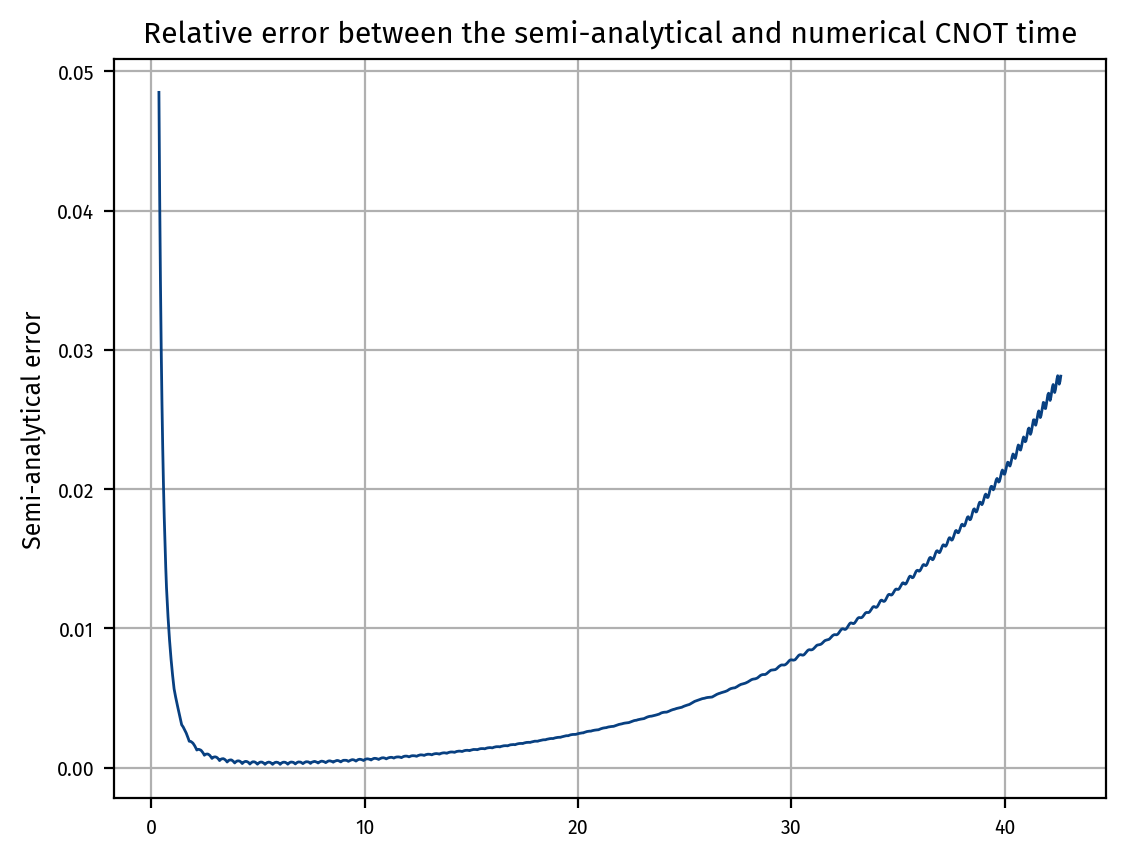

In [27]:
plt.title("Relative error between the semi-analytical and numerical CNOT time")
plt.plot(
    dataset_amplitude_sweep.amplitude.data,
    1 - cnot_rate_semi_analytic_data * dataset_amplitude_sweep.total_duration.squeeze().data
)
plt.ylabel("Semi-analytical error")
plt.grid()